# Resampling the EVI Timeseries Data

The EVI timeseries obtained from NASA Earthdata is generally sampled every 16 days. However, some data points are sampled at 14- and 13-day intervals, and there is a missing data point in mid-January 2001.
In this script, we take the EVI netCDF file and resample it in time, applying the nearest neighbor sampling method.

In [ ]:
# needed libraries 
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# open dataset of EVI with chunking (chunks={"time": -1})
evi_netCDF = xr.open_dataset("EVI_time_series_scaled.nc", chunks={"time": -1, "lat": 100, "lon": 100}) # use chunking for efficient access (dask library might need to be installed)

# check structure makes sense
print(evi_netCDF)
min(evi_netCDF["time"].values), max(evi_netCDF["time"].values)

<xarray.Dataset> Size: 60GB
Dimensions:  (time: 578, lat: 3600, lon: 7200)
Coordinates:
  * time     (time) datetime64[ns] 5kB 2000-02-18 2000-03-05 ... 2025-04-07
  * lat      (lat) float64 29kB 89.97 89.92 89.88 89.83 ... -89.87 -89.92 -89.97
  * lon      (lon) float64 58kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    EVI      (time, lat, lon) float32 60GB dask.array<chunksize=(578, 100, 100), meta=np.ndarray>


(numpy.datetime64('2000-02-18T00:00:00.000000000'),
 numpy.datetime64('2025-04-07T00:00:00.000000000'))

In [3]:
#  create regular time index
time_index = pd.date_range(start="2000-02-18", end="2025-04-07", freq="16D")
print(time_index)

DatetimeIndex(['2000-02-18', '2000-03-05', '2000-03-21', '2000-04-06',
               '2000-04-22', '2000-05-08', '2000-05-24', '2000-06-09',
               '2000-06-25', '2000-07-11',
               ...
               '2024-11-02', '2024-11-18', '2024-12-04', '2024-12-20',
               '2025-01-05', '2025-01-21', '2025-02-06', '2025-02-22',
               '2025-03-10', '2025-03-26'],
              dtype='datetime64[ns]', length=574, freq='16D')


In [ ]:
# resample using nearest in time
evi_netCDF_resampled_nearest = evi_netCDF.reindex(time=time_index, method="nearest", tolerance=pd.Timedelta("8D")) # because I chuncked the original dataset I should be able to resample it in chuncks

# the tolerance is set to 8 days to avoid matching to points that are too far away (more than half the 16-day interval), 
# this automatically excludes all areas that have longer periods of missing data, such as the 2001-01-19 date, 
# but also areas north of ~62 degrees latitude or south of ~60 degrees latitude that have seasonal missing data due to snow cover

# Rechunk the result to reduce chunk multiplication
evi_netCDF_resampled_nearest = evi_netCDF_resampled_nearest.chunk({"time": -1, "lat": 100, "lon": 100})
# check structure makes sense
print(evi_netCDF_resampled_nearest)

<xarray.Dataset> Size: 60GB
Dimensions:  (time: 574, lat: 3600, lon: 7200)
Coordinates:
  * time     (time) datetime64[ns] 5kB 2000-02-18 2000-03-05 ... 2025-03-26
  * lat      (lat) float64 29kB 89.97 89.92 89.88 89.83 ... -89.87 -89.92 -89.97
  * lon      (lon) float64 58kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    EVI      (time, lat, lon) float32 60GB dask.array<chunksize=(574, 100, 100), meta=np.ndarray>


/Users/gb4818/code/vegetation-wavelets-workflow/.venv/lib/python3.9/site-packages/dask/array/core.py:4849: PerformanceWarning: Increasing number of chunks by factor of 36
  result = blockwise(


There is a mising datapoint for 2001-01-19, this HDF file was actually missing from NASA Earthdata. In this case I want to interpolate it linearly. Only this point. 

In [ ]:
# Identify the time indice to interpolate
target_time = np.datetime64('2001-01-19')

# Find the index of the target time in the time coordinate
try:
    idx_missing = evi_netCDF_resampled_nearest.time.to_index().get_loc(target_time)
except KeyError:
    raise ValueError(f"Time {target_time} not found in the dataset.")

# Get indices of neighboring time points
t_prev_idx = idx_missing - 1
t_next_idx = idx_missing + 1

# Ensure the indices are valid
if t_prev_idx < 0 or t_next_idx >= len(evi_netCDF_resampled_nearest.time):
    raise IndexError("Target time is at the edge of the time dimension.")


In [ ]:
# Extract necessary time slices from the dataset
evi = evi_netCDF_resampled_nearest['EVI']
evi_prev = evi.isel(time=t_prev_idx)
evi_missing = evi.isel(time=idx_missing)
evi_next = evi.isel(time=t_next_idx)

# Calculate time differences in days
t_prev = evi_netCDF_resampled_nearest.time[t_prev_idx].values
t_next = evi_netCDF_resampled_nearest.time[t_next_idx].values

In [ ]:

time_diff_days = (t_next - t_prev).astype('timedelta64[D]').astype(int)
time_missing_diff_days = (target_time - t_prev).astype('timedelta64[D]').astype(int)

# computing interpolation weight
weight = time_missing_diff_days / time_diff_days

# linear interpolation for point in question
interpolated_values = evi_prev + weight * (evi_next - evi_prev)

# create a mask where EVI is NaN at the target time
mask = evi_missing.isnull()

# apply interpolated values only where needed
evi_corrected = xr.where(
    (evi.time == evi_netCDF_resampled_nearest.time[idx_missing]) & mask,
    interpolated_values,
    evi
)

# Update the original dataset's EVI variable
evi_netCDF_resampled_nearest['EVI'] = evi_corrected

# Save the full dataset (preserving all variables), this might take a while, it took 20 mins on my laptop
evi_netCDF_resampled_nearest.to_netcdf('EVI_time_series_scales_interpolated_nearest_v2.nc')

In [15]:
## Rechunk the result to reduce chunk multiplication (optional)
new_correct = xr.open_dataset("EVI_time_series_scales_interpolated_nearest_v2.nc", chunks={})
print(new_correct)

evi_netCDF_resampled_nearest=new_correct

<xarray.Dataset> Size: 60GB
Dimensions:  (time: 574, lat: 3600, lon: 7200)
Coordinates:
  * time     (time) datetime64[ns] 5kB 2000-02-18 2000-03-05 ... 2025-03-26
  * lat      (lat) float64 29kB 89.97 89.92 89.88 89.83 ... -89.87 -89.92 -89.97
  * lon      (lon) float64 58kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    EVI      (time, lat, lon) float32 60GB dask.array<chunksize=(574, 3600, 7200), meta=np.ndarray>


In [ ]:
# visually examine the resampled data vs the original data
lat = 10
lon= 44

# interpolated point
new_point = evi_netCDF_resampled_nearest["EVI"].sel(lat=lat, lon=lon, method="nearest").compute()
sig3 = new_point.values
dates3 = new_point['time'].values
print(dates3)

# original point
original_point = evi_netCDF["EVI"].sel(lat=lat, lon=lon, method="nearest").compute()
sig1 = original_point.values
dates1 = original_point['time'].values
print(dates1)


['2000-02-18T00:00:00.000000000' '2000-03-05T00:00:00.000000000'
 '2000-03-21T00:00:00.000000000' '2000-04-06T00:00:00.000000000'
 '2000-04-22T00:00:00.000000000' '2000-05-08T00:00:00.000000000'
 '2000-05-24T00:00:00.000000000' '2000-06-09T00:00:00.000000000'
 '2000-06-25T00:00:00.000000000' '2000-07-11T00:00:00.000000000'
 '2000-07-27T00:00:00.000000000' '2000-08-12T00:00:00.000000000'
 '2000-08-28T00:00:00.000000000' '2000-09-13T00:00:00.000000000'
 '2000-09-29T00:00:00.000000000' '2000-10-15T00:00:00.000000000'
 '2000-10-31T00:00:00.000000000' '2000-11-16T00:00:00.000000000'
 '2000-12-02T00:00:00.000000000' '2000-12-18T00:00:00.000000000'
 '2001-01-03T00:00:00.000000000' '2001-01-19T00:00:00.000000000'
 '2001-02-04T00:00:00.000000000' '2001-02-20T00:00:00.000000000'
 '2001-03-08T00:00:00.000000000' '2001-03-24T00:00:00.000000000'
 '2001-04-09T00:00:00.000000000' '2001-04-25T00:00:00.000000000'
 '2001-05-11T00:00:00.000000000' '2001-05-27T00:00:00.000000000'
 '2001-06-12T00:00:00.000

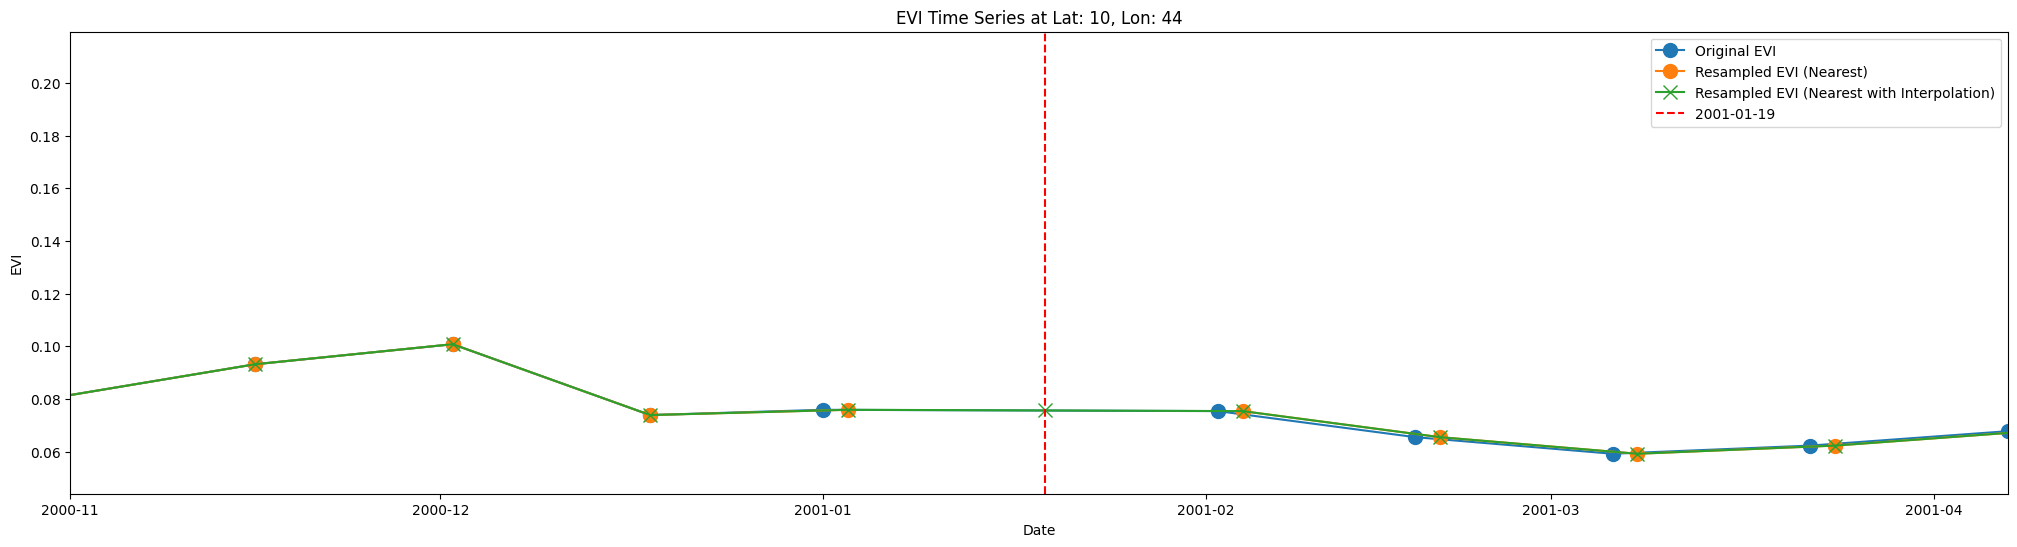

In [ ]:
# Visual Inspection
plt.figure(figsize=(25, 6))
plt.plot(dates1, sig1, label="Original EVI", marker='o', linestyle='-', markersize=10)
plt.plot(dates3, sig3, label="Resampled EVI (Nearest with Interpolation)", marker='x', markersize=10)
missing_date = pd.to_datetime("2001-01-19")
plt.axvline(missing_date, color='red', linestyle='--', label='2001-01-19')
plt.xlabel("Date")
plt.ylabel("EVI")
plt.title(f"EVI Time Series at Lat: {lat}, Lon: {lon}")
plt.xlim(pd.to_datetime("2000-11-01"), pd.to_datetime("2001-04-07"))
plt.legend()
plt.show()